# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [3]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [4]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file = 'Churn_Modelling.csv'

In [6]:
## TODO : make into a dataframe called df
df = pd.read_csv(file)

In [9]:
## TODO : output the first 5 lines
print(df.head())
print(f'Dataset has {df.shape[0]} row, {df.shape[1]} columns')
print(df.info())
print('Missing values: ')
print(df.isnull().sum())
print(f'Data types: {df.dtypes}')
print(f' Data basic statistics: \n ')
print(df.describe())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [ ]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively

df_0 = df[df['Exited'] == 0.0]
df_1 = df[df['Exited'] == 1.0]

RowNumber          2037
CustomerId         2037
Surname            2037
CreditScore        2037
Geography          2037
Gender             2037
Age                2037
Tenure             2037
Balance            2037
NumOfProducts      2037
HasCrCard          2037
IsActiveMember     2037
EstimatedSalary    2037
Exited             2037
dtype: int64

## Hypothesis 1: Age

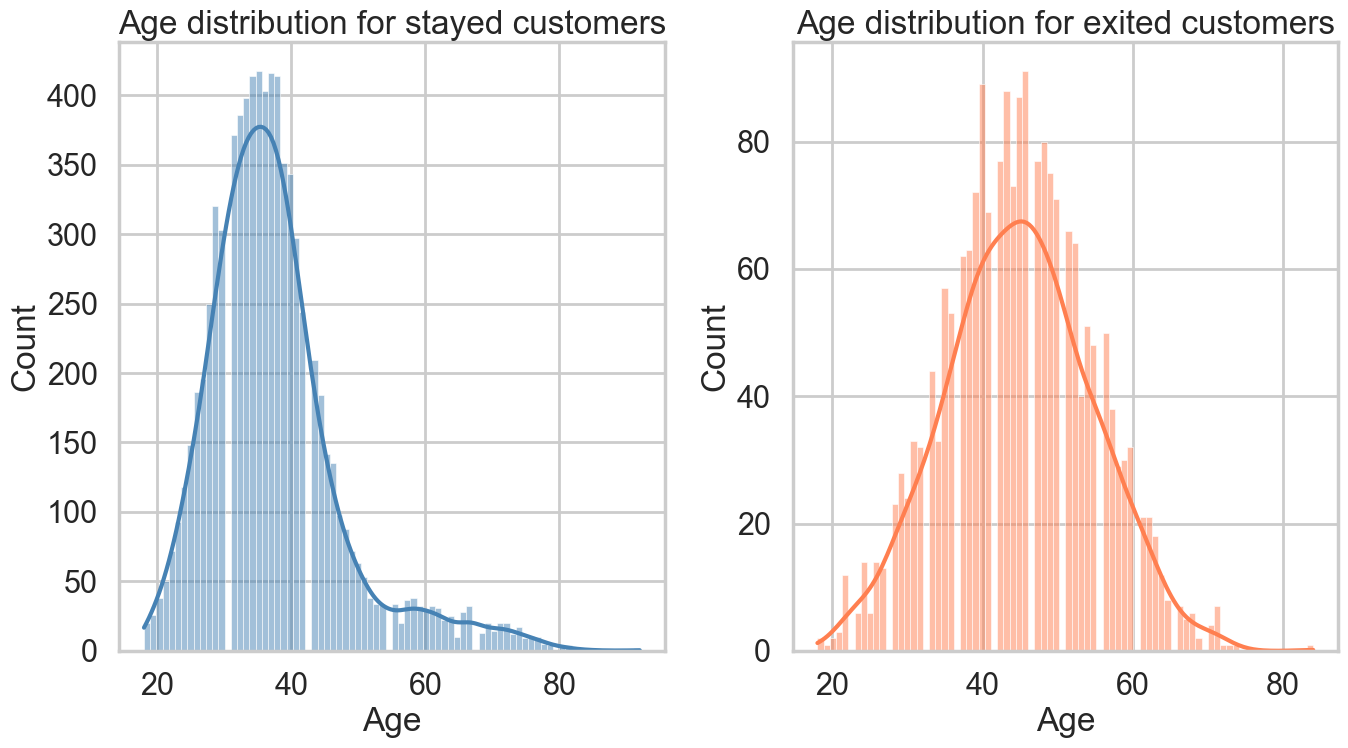

In [55]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(data=df_0, x='Age',kde=True, bins=80, color='steelblue', ax=axes[0])
axes[0].set_title('Age distribution for stayed customers')

sns.histplot(data=df_1, x='Age', kde=True,bins=80,color='coral', ax=axes[1])
axes[1].set_title('Age distribution for exited customers')

plt.tight_layout()
plt.show()



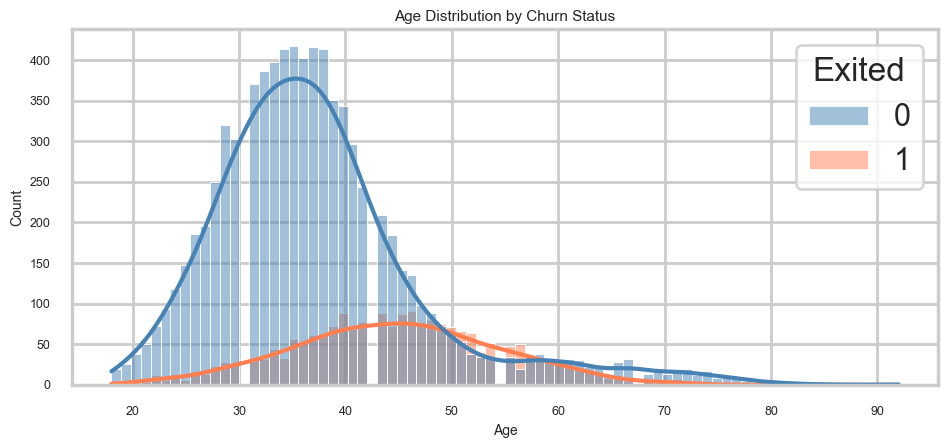

In [50]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Exited', kde=True, bins=80, palette=['steelblue', 'coral'])
plt.title('Age Distribution by Churn Status', fontsize=11)
plt.xlabel('Age', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [ ]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.

age_mean_stayed = df_0['Age'].mean()
age_std_stayed = df_0['Age'].std()
age_mean_exited = df_1['Age'].mean()
age_std_exited = df_1['Age'].std()
print(f'Stayed customers:')
print(f"mean: {age_mean_stayed:.2f}, std: {age_std_stayed:.2f}")
print(f'Exited customers:')
print(f"mean: {age_mean_exited:.2f}, std: {age_std_exited:.2f}")


Stayed customers:
mean: 37.41, std: 10.13
Exited customers:
mean: 44.84, std: 9.76


In [21]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
import scipy.stats as stats
t_stat, p_value = stats.ttest_ind(df_0['Age'], df_1['Age'])
print(f"T-statistics: {t_stat}, P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print('There is a significant difference on Age between customers who stayed and exited.')
else:
    print('There is no significant difference on Age between customers who stayed and exited ')


T-statistics: -29.76681499437077, P-value: 0.0000
There is a significant difference on Age between customers who stayed and exited.


### Using Bootstrapping

In [36]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, len(data), replace=True)
        bs_s[i] = func(bs_abc)
    return bs_s

In [ ]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
observed_diff_age = df_0['Age'].mean() - df_1['Age'].mean()
print(f'The actual mean age difference: {observed_diff_age}')
overall_mean = df['Age'].mean()
print(f'The actual overall mean age is {overall_mean}')


# shift mean
df_0_age_shift = df_0['Age'] + overall_mean - df_0['Age'].mean()
df_1_age_shift = df_1['Age'] + overall_mean - df_1['Age'].mean()



The actual mean age difference: -7.429608256300263
The actual overall mean age is 38.9218


BS resampling for df_0 mean:
 38.89, 38.82, 39.03, 38.83, 38.97, 39.05, 38.96, 38.93, 38.92, 38.87
BS resampling for df_1 mean:
 38.77, 38.71, 39.26, 38.83, 38.79, 38.85, 39.13, 38.99, 38.88, 39.35
age differences of both mean group:
 0.12, 0.12, -0.23, -0.00, 0.17, 0.19, -0.17, -0.07, 0.04, -0.48
Std of stayed customers age means: 0.1133
Std of exited customers age means: 0.2140
Std of difference: 0.2429


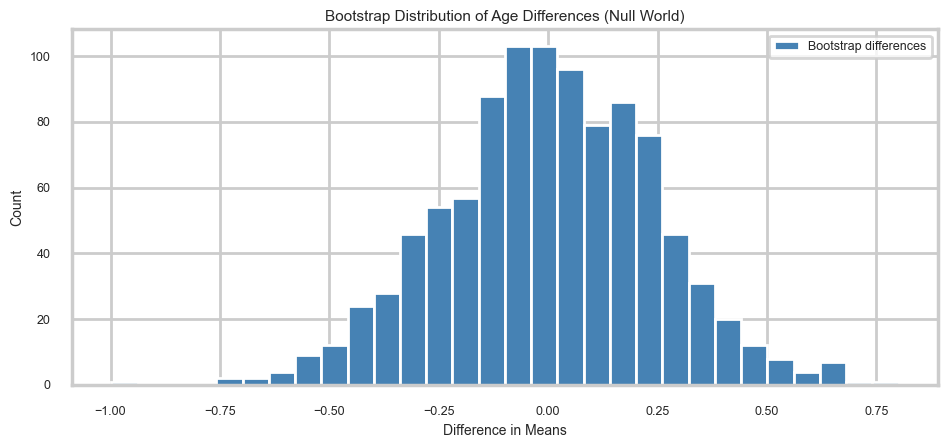

In [45]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.

bs_s_0 = bs_choice(df_0_age_shift, np.mean, 1000)
bs_s_1 = bs_choice(df_1_age_shift, np.mean, 1000)

values_bs0 = ', '.join(f"{x:.2f}" for x in bs_s_0[:10])
values_bs1 = ', '.join(f"{x:.2f}" for x in bs_s_1[:10])

print(f'BS resampling for df_0 mean:\n {values_bs0}')
print(f'BS resampling for df_1 mean:\n {values_bs1}')


bs_s_0_std = np.std(bs_s_0)
bs_s_1_std = np.std(bs_s_1)

bs_diff = bs_s_0 - bs_s_1
values_bs_diff = ', '.join(f"{x:.2f}" for x in bs_diff[:10])

print(f'age differences of both mean group:\n {values_bs_diff}')
std_diff = np.std(bs_diff)

print(f"Std of stayed customers age means: {bs_s_0_std:.4f}")
print(f"Std of exited customers age means: {bs_s_1_std:.4f}")
print(f"Std of difference: {std_diff:.4f}")

plt.figure(figsize=(10, 5))
plt.hist(bs_diff, bins=30, color='steelblue', edgecolor='white', label='Bootstrap differences')
# plt.axvline(observed_diff_age, color='red', linestyle='--', linewidth=1.5, label=f'Observed diff: {observed_diff_age:.2f}')
# plt.axvline(-observed_diff_age, color='orange', linestyle='--', linewidth=1.5, label=f'Negative observed diff: {-observed_diff_age:.2f}')
plt.title('Bootstrap Distribution of Age Differences (Null World)', fontsize=11)
plt.xlabel('Difference in Means', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()



In [56]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
# p_value = np.mean(np.abs(bs_diff) >= np.abs(observed_diff_age))
p_value = np.sum(np.abs(bs_diff) >= np.abs(observed_diff_age)) / len(bs_diff)

print(p_value)
alpha = 0.05
if p_value < alpha:
    print('There IS a significant difference in Age between customers who stayed and exited.')
else:
    print('There is NO significant difference in Age between customers who stayed and exited ')



0.0
There IS a significant difference in Age between customers who stayed and exited.


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Hypothesis 2: Credit Score

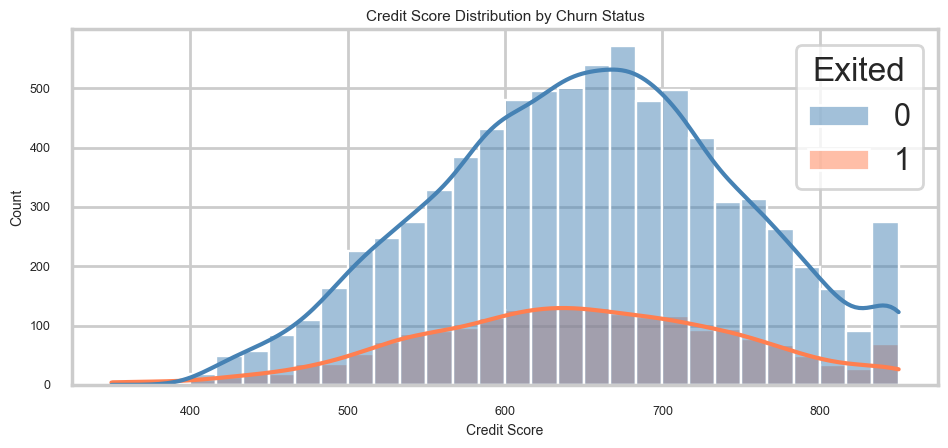

In [63]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='CreditScore', hue='Exited', bins=30, kde=True, palette=['steelblue', 'coral'])
plt.title('Credit Score Distribution by Churn Status', fontsize=11)
plt.xlabel('Credit Score', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [68]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

df_0_CS = df[df['Exited']==0.0]['CreditScore']
df_1_CS = df[df['Exited']==1.0]['CreditScore']
df_0_CS_mean = df_0_CS.mean()
df_1_CS_mean = df_1_CS.mean()

print(f'mean of credit score for customers stayed: {df_0_CS_mean:.2f}')
print(f'mean of credit score for customers exited: {df_1_CS_mean:.2f}')


t_stat_cs, p_value_cs = stats.ttest_ind(df_0_CS, df_1_CS)
print(f'T-test p-value: {p_value_cs}')
alpha = 0.05
if p_value_cs < alpha:
    print('Reject H0: There is a significant difference in Credit Score between customers who stayed and exited.')
else:
    print('Failed to reject H0: There is no significant difference in Credit Score between customers who stayed and exited ')



mean of credit score for customers stayed: 651.85
mean of credit score for customers exited: 645.35
T-test p-value: 0.0067382138921923745
Reject H0: There is a significant difference in Credit Score between customers who stayed and exited.


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Hypothesis 3: Balance

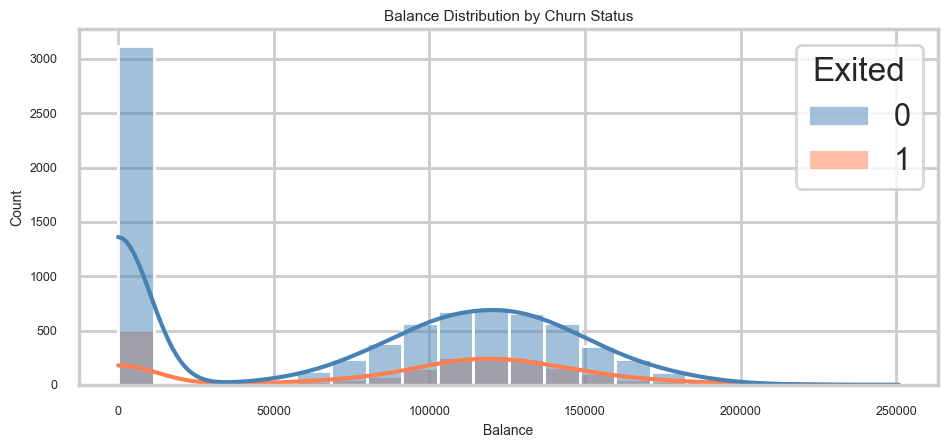

In [ ]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Balance', hue='Exited',  kde=True, palette=['steelblue', 'coral'])
plt.title('Balance Distribution by Churn Status', fontsize=11)
plt.xlabel('Balance', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()


In [72]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
df_0_blc = df[df['Exited']==0.0]['Balance']
df_1_blc = df[df['Exited']==1.0]['Balance']
df_0_blc_mean = df_0_blc.mean()
df_1_blc_mean = df_1_blc.mean()

print(f'mean of balance for customers stayed: {df_0_blc_mean:.2f}')
print(f'mean of balance score for customers exited: {df_1_blc_mean:.2f}')


t_stat_blc, p_value_blc = stats.ttest_ind(df_0_blc, df_1_blc)
print(f'T-test p-value: {p_value_blc:.4f}')
alpha = 0.05
if p_value_blc < alpha:
    print('Reject H0: There is a significant difference in Balance between customers who stayed and exited.')
else:
    print('Failed to reject H0: There is no significant difference in Balance between customers who stayed and exited ')

mean of balance for customers stayed: 72745.30
mean of balance score for customers exited: 91108.54
T-test p-value: 0.0000
Reject H0: There is a significant difference in Balance between customers who stayed and exited.


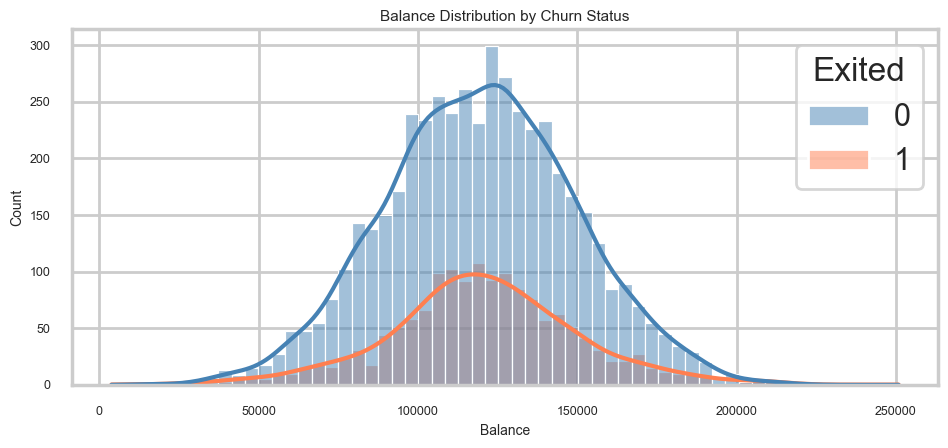

In [73]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
df_nonzero = df[df['Balance'] > 0]

plt.figure(figsize=(10, 5))
sns.histplot(data=df_nonzero, x='Balance', hue='Exited',  kde=True, palette=['steelblue', 'coral'])
plt.title('Balance Distribution by Churn Status', fontsize=11)
plt.xlabel('Balance', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [74]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

df_0_blc = df_nonzero[df_nonzero['Exited']==0.0]['Balance']
df_1_blc = df_nonzero[df_nonzero['Exited']==1.0]['Balance']
df_0_blc_mean = df_0_blc.mean()
df_1_blc_mean = df_1_blc.mean()

print(f'mean of balance for customers stayed: {df_0_blc_mean:.2f}')
print(f'mean of balance score for customers exited: {df_1_blc_mean:.2f}')


t_stat_blc, p_value_blc = stats.ttest_ind(df_0_blc, df_1_blc)
print(f'T-test p-value: {p_value_blc:.4f}')
alpha = 0.05
if p_value_blc < alpha:
    print('Reject H0: There is a significant difference in Balance between customers who stayed and exited.')
else:
    print('Failed to reject H0: There is no significant difference in Balance between customers who stayed and exited ')

mean of balance for customers stayed: 119535.86
mean of balance score for customers exited: 120746.97
T-test p-value: 0.1692
Failed to reject H0: There is no significant difference in Balance between customers who stayed and exited 


## Conclusion

Do we reject the Null Hypothesis ? Why ?

## Hypothesis 4: Estimated Salary

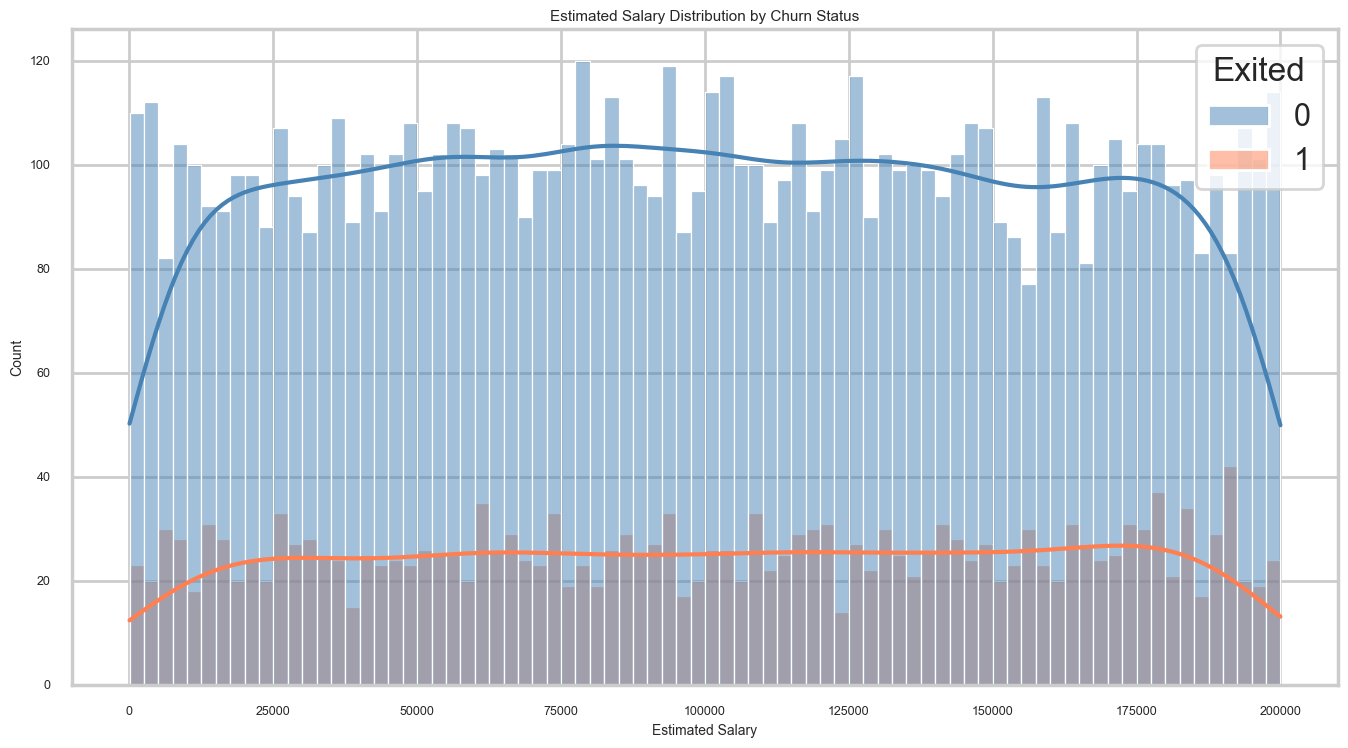

In [85]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
plt.figure(figsize=(14, 8))
sns.histplot(data=df, x='EstimatedSalary', hue='Exited', bins=80, kde=True, palette=['steelblue', 'coral'])
plt.title('Estimated Salary Distribution by Churn Status', fontsize=11)
plt.xlabel('Estimated Salary', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [86]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
df_0_es = df[df['Exited']==0.0]['EstimatedSalary']
df_1_es = df[df['Exited']==1.0]['EstimatedSalary']
df_0_es_mean = df_0_es.mean()
df_1_es_mean = df_1_es.mean()

print(f'mean of Estimated Salary for customers stayed: {df_0_es_mean:.2f}')
print(f'mean of Estimated Salary score for customers exited: {df_1_es_mean:.2f}')


t_stat_es, p_value_es = stats.ttest_ind(df_0_es, df_1_es)
print(f'T-test p-value: {p_value_es:.4f}')
alpha = 0.05
if p_value_es < alpha:
    print('Reject H0: There is a significant difference in Estimated Salary between customers who stayed and exited.')
else:
    print('Failed to reject H0: There is no significant difference in Estimated Salary between customers who stayed and exited ')

mean of Estimated Salary for customers stayed: 99738.39
mean of Estimated Salary score for customers exited: 101465.68
T-test p-value: 0.2264
Failed to reject H0: There is no significant difference in Estimated Salary between customers who stayed and exited 


### Using Bootstrapping

In [89]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
observed_diff_salary = df_0_es_mean - df_1_es_mean
print(f"observed_diff_salary: {observed_diff_salary}")
overall_mean_salary = df['EstimatedSalary'].mean()
print(f"overall_mean_salary: {overall_mean_salary}")

df_0_es_shifted = df_0_es + overall_mean_salary - df_0_es_mean
df_1_es_shifted = df_1_es + overall_mean_salary - df_1_es_mean




observed_diff_salary: -1727.2857587371254
overall_mean_salary: 100090.239881


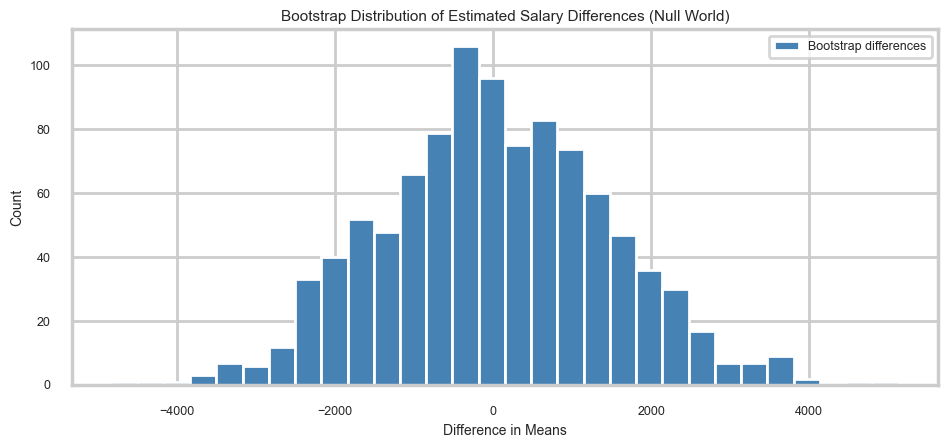

In [90]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.

bs_0_es = bs_choice(df_0_es_shifted, np.mean, 1000)
bs_1_es = bs_choice(df_1_es_shifted, np.mean, 1000)
bs_es_diff = bs_0_es - bs_1_es

plt.figure(figsize=(10, 5))
plt.hist(bs_es_diff, bins=30, color='steelblue', edgecolor='white', label='Bootstrap differences')
# plt.axvline(observed_diff_age, color='red', linestyle='--', linewidth=1.5, label=f'Observed diff: {observed_diff_age:.2f}')
# plt.axvline(-observed_diff_age, color='orange', linestyle='--', linewidth=1.5, label=f'Negative observed diff: {-observed_diff_age:.2f}')
plt.title('Bootstrap Distribution of Estimated Salary Differences (Null World)', fontsize=11)
plt.xlabel('Difference in Means', fontsize=10)
plt.ylabel('Count', fontsize=10)
plt.tick_params(labelsize=9)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [91]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.

bs_p_value_es = np.sum( np.abs(bs_es_diff) >= np.abs(observed_diff_salary) )/len(bs_es_diff)
print(f'Bootstrap Hypothesis test p-value: {bs_p_value_es}')

if bs_p_value_es <= 0.05:
    print('There is a significant difference in Estimated Salary between customers who stayed and exited.')
else:
    print('There is no significant difference in Estimated Salary between customers who stayed and exited ')


Bootstrap Hypothesis test p-value: 0.244
There is no significant difference in Estimated Salary between customers who stayed and exited 


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Final Conclusion
What will be the most helpful feature in predicting churning?


1. **Age** — showed a statistically significant difference between churned and 
   retained customers (p-value ≈ 0.000). Churned customers tend to be older.
   This is likely the strongest predictor of churn.

2. **Balance** — churned customers tend to have higher balances compared to 
   retained customers (visible from the distribution plot).
   But after removing the zero balanced customer, there's no significant difference on balance between two groups.

3. **Credit Score** — showed difference between the two groups. but the data was caped at 850 credit score , which could affect the mean for both groups, hence affecting the t-test.

4. **Estimated Salary** - showed no significant difference between two groups.

**Conclusion:** Age is the most helpful feature in predicting churn, supported 
by both the bootstrap hypothesis test (p < 0.05) and the visual distribution 
showing a clear separation between the two groups.